In [1]:
from xmitgcm import llcreader
aste = llcreader.CRIOSPortalASTE270Model()
import os
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import cartopy as cart
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as patches
import matplotlib.colors as colors
import matplotlib.cm as cm
import ecco_v4_py
from ecco_v4_py import vector_calc, scalar_calc
from scipy.io import loadmat


# setting up a dask LocalCluster
from dask.distributed import Client
from dask.distributed import LocalCluster
cluster = LocalCluster()
client = Client(cluster)
client.get_task_stream()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 8,Total memory: 64.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39177,Workers: 4
Dashboard: http://127.0.0.1:8787/status,Total threads: 8
Started: Just now,Total memory: 64.00 GiB
Comm: tcp://127.0.0.1:38859,Total threads: 2
Dashboard: http://127.0.0.1:44375/status,Memory: 16.00 GiB
Nanny: tcp://127.0.0.1:36121,


In [2]:
ds = aste.get_dataset(varnames=['THETA', 'SALT', 'MXLDEPTH'])

#Define variables
theta = ds.THETA
mxl = ds.MXLDEPTH
salt = ds.SALT
fig = plt.figure(figsize=(14,6))

filepath = "/rds/general/user/sl8924/home/ASTE_data/other_data/Argo_mixedlayers_all_04142022.nc"
argo = xr.open_dataset(filepath)
argo
argo_mld = argo.da_mld
argo_mld

#Load argo data
file_path =  '/rds/general/user/sl8924/home/Kuhlbrodt_analysis/observational_data/labsea_24b.mat'
argo_float = loadmat(file_path)

argo_lon = argo_float['lon']
argo_lat = argo_float['lat']

#load SPG area 
file_path = '/rds/general/user/sl8924/home/Kuhlbrodt_analysis/observational_data/adt_spg_contour.mat'
spg_area = loadmat(file_path)
spg_lat = spg_area['cla']
spg_lon = spg_area['clo']

spg_lon1  = np.transpose(spg_lon)
spg_lat1 = np.transpose(spg_lat)
argo_lon1 = argo_lon - 360

<Figure size 1400x600 with 0 Axes>

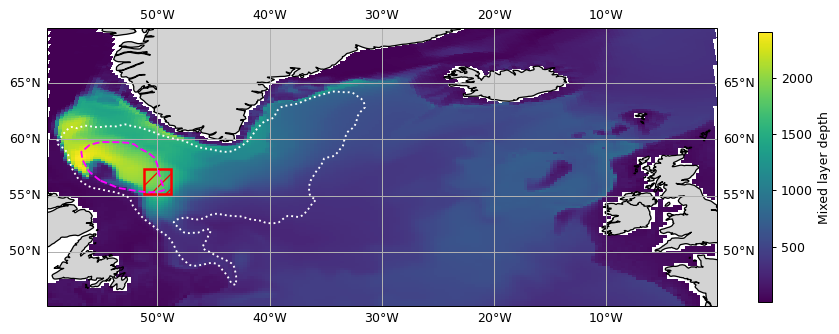

In [3]:
#Plot Figure 1

t = 2
point = theta.isel(face=4, i=98, j= 235, time=t)
mxl1 = mxl.isel(time=t)
mxl1 = mxl1.where((mxl.YC <= 70) & (mxl.YC >= 45) & (mxl.XC <= 0) & (mxl.XC >= -60))

# Extract coordinates and data for face 1 (filter NaNs)
tile1 = mxl1.isel(face=1)
valid1 = ~np.isnan(tile1)
lons1 = tile1.XC.where(valid1)
lats1 = tile1.YC.where(valid1)

# Extract coordinates and data for face 4
tile4 = mxl1.isel(face=4)
valid4 = ~np.isnan(tile4)
lons4 = tile4.XC.where(valid4)
lats4 = tile4.YC.where(valid4)

# Set color limits based on non-nan values
vmin, vmax = np.nanmin(tile4.values), np.nanmax(tile4.values)

# Plot
fig, ax = plt.subplots(figsize=(12, 6), dpi=90, subplot_kw={"projection": ccrs.PlateCarree()})
cf1 = ax.pcolor(lons1, lats1, tile1, transform=ccrs.PlateCarree(), vmin=vmin, vmax=vmax, cmap='viridis')
cf2 = ax.pcolor(lons4, lats4, tile4, transform=ccrs.PlateCarree(), vmin=vmin, vmax=vmax, cmap='viridis')

ax.coastlines()
ax.add_feature(cfeature.LAND, color="lightgray")
ax.add_feature(cfeature.BORDERS)
ax.gridlines(draw_labels=True)
cbar = fig.colorbar(cf1, shrink=0.65)
cbar.set_label('Mixed layer depth')

#Add argofloats region 
ax.plot(argo_lon1, argo_lat, transform = ccrs.PlateCarree(), color='magenta', linestyle='--')

#Add SPG area
ax.plot(spg_lon1, spg_lat1, transform=ccrs.PlateCarree(), color='white', linestyle=':')



box = patches.Rectangle(
    (-51.2, 55.1),  # (longitude, latitude) of bottom-left corner
    2.4,  # width 
    2.3,  #height
    linewidth=2,  # border width
    edgecolor='red',  # box color
    facecolor='none',  # no fill color
    alpha=1,
    linestyle='-', 
    hatch='//'
)
ax.add_patch(box)
plt.show()

In [4]:
#Create datasets of S and T at centre of deep convection for the 50m box 
ds1 = ds.isel(k=slice(0,6)) 
ds2 = ds.isel(k=slice(17, 38))

theta1 = theta.isel(k=slice(0,6), face=4)
theta1 = theta1.where((ds.i <= 100) & (ds.i >= 87) & (ds.j <= 237) & (ds.j >= 230))
T_1 = theta1.mean(dim=['k', 'i', 'j'])


salt1 = salt.isel(k=slice(0,6), face=4)
salt1 = salt1.where((ds.i <= 100) & (ds.i >= 87) & (ds.j <= 237) & (ds.j >= 230))
S_1 = salt1.mean(dim=['k', 'i', 'j'])

theta2 = theta.isel(k=slice(17, 38), face=4)
theta2 = theta2.where((ds.i <= 100) & (ds.i >= 87) & (ds.j <= 237) & (ds.j >= 230))
T_2 = theta2.mean(dim=['k', 'i', 'j'])

salt2 = salt.isel(k=slice(17,38), face=4)
salt2 = salt2.where((ds.i <= 100) & (ds.i >= 87) & (ds.j <= 237) & (ds.j >= 230))
S_2 = salt2.mean(dim=['k', 'i', 'j'])


In [ ]:
#Create datasets of S and T at centre of deep convection for the 200m box 
ds1 = ds.isel(k=slice(0,17)) 
ds2 = ds.isel(k=slice(17, 38))

theta1 = theta.isel(k=slice(0,17), face=4)
theta1 = theta1.where((ds.i <= 100) & (ds.i >= 87) & (ds.j <= 237) & (ds.j >= 230))
T_1 = theta1.mean(dim=['k', 'i', 'j'])


salt1 = salt.isel(k=slice(0,17), face=4)
salt1 = salt1.where((ds.i <= 100) & (ds.i >= 87) & (ds.j <= 237) & (ds.j >= 230))
S_1 = salt1.mean(dim=['k', 'i', 'j'])

theta2 = theta.isel(k=slice(17, 38), face=4)
theta2 = theta2.where((ds.i <= 100) & (ds.i >= 87) & (ds.j <= 237) & (ds.j >= 230))
T_2 = theta2.mean(dim=['k', 'i', 'j'])

salt2 = salt.isel(k=slice(17,38), face=4)
salt2 = salt2.where((ds.i <= 100) & (ds.i >= 87) & (ds.j <= 237) & (ds.j >= 230))
S_2 = salt2.mean(dim=['k', 'i', 'j'])